In [1]:
import numpy as np
from scipy.io.wavfile import read
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from IPython.display import Audio, display

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

### Preprocessing data

In [2]:
def create_dataset(X_data, y_data, look_back=1):
    dataX, dataY = [], []
    for i in range(len(X_data)-look_back-1):
        a = X_data[i:(i+look_back), 0]
        dataX.append(a)
        dataY.append(y_data[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

* Last 20% of data is validation
* Loss: signal to error ratio

In [ ]:
_, data = read("Data\ML_Guitar_Initial_Data.wav")
_, target = read("Data/Ml_Guitar_Target_Data.wav")
# display(Audio(data[:,0], rate = 44100/8))
# display(Audio(target[:,0], rate = 44100))

data = data[:,0]      # Sound is in two channels but these are basically equal
target = target[:,0]
y = target - data

# Split into train and test sets
train_size = int(len(data) * 0.1)
test_size = int(len(data) * 0.01)
use_every = 8
trainX, valX = data[:train_size:use_every].reshape(-1, 1), data[-test_size::use_every].reshape(-1, 1)  
display(Audio(trainX.flatten(), rate = 44100/use_every))
trainy, valy = y[:train_size:use_every].reshape(-1, 1)  , y[-test_size::use_every].reshape(-1, 1)  

X_scaler = MinMaxScaler(feature_range=(-1, 1)).fit(trainX)
X_train = X_scaler.transform(trainX)
X_val = X_scaler.transform(valX)

y_scaler = MinMaxScaler(feature_range=(-1, 1)).fit(trainy)
y_train = y_scaler.transform(trainy)
y_val = y_scaler.transform(valy)

# Reshape into X = t and Y = t + 1, and include the last 5 entries in prediction:
look_back = 64
X_train, y_train = create_dataset(X_train, y_train, look_back)
X_val, y_val = create_dataset(X_val, y_val, look_back)

# Reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

In [4]:
# Move to PyTorch tensors:
X_train = torch.tensor(X_train, dtype=torch.float)
y_train = torch.tensor(y_train, dtype=torch.float)
X_val = torch.tensor(X_val, dtype=torch.float)
y_val = torch.tensor(y_val, dtype=torch.float)

### Creating model

In [96]:
class Net(nn.Module):
    def __init__(self, input_size = 1, hidden_size=128):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, out_features=input_size)
        
    def forward(self, x):
        x, _ = self.lstm(x)  # Run LSTM and store the hidden layer outputs
        x = x[:, -1, :]  # take the last hidden layer
        x = self.linear(x) # a normal dense layer
        return x

In [97]:
net = Net()
opt = torch.optim.Adam(net.parameters(), lr=5e-3)
progress_bar = tqdm(range(100))
loss_arr = []
for epoch in progress_bar:
    prediction = net(X_train)
    loss = torch.sum((prediction.flatten() - y_train.flatten())**2/y_train.flatten()**2)
    progress_bar.set_description(f'Loss = {float(loss):6.4f}')
    loss.backward()
    loss_arr.append(float(loss))
    opt.step()
    opt.zero_grad()

Loss = 11133.6465: 100%|██████████| 100/100 [06:08<00:00,  3.68s/it]


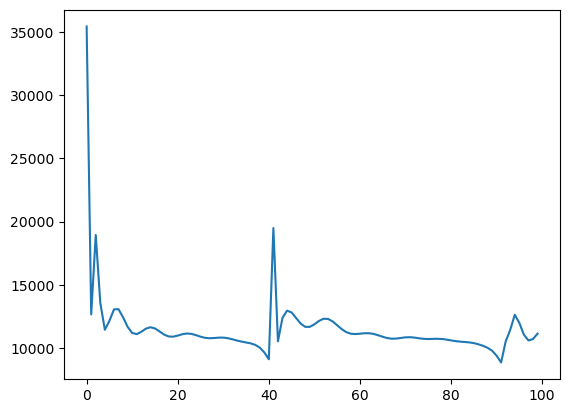

: 

In [ ]:
plt.plot(loss_arr)

In [ ]:
# Make predictions:
with torch.no_grad():
    pred = net(X_val).numpy()

pred = y_scaler.inverse_transform(pred)
y_out = X_val + pred

In [ ]:
display(Audio(pred.flatten(), rate=44100/8))
display(Audio(y_val.flatten(), rate=44100/8))

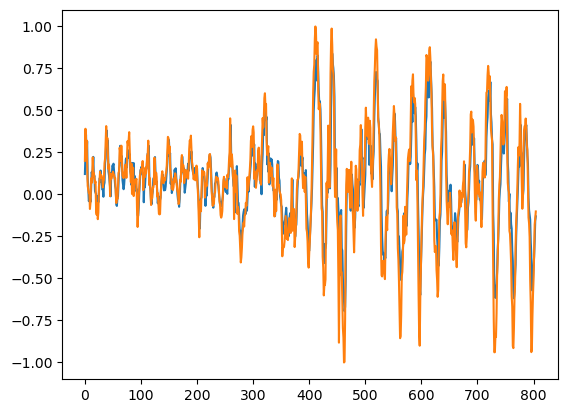

In [ ]:
plt.plot(pred)
plt.plot(y_val)

In [ ]:


# Invert predictions:
trainPredict = scaler.inverse_transform(trainPredict)
trainY_inv = scaler.inverse_transform([trainY.numpy()])
testPredict = scaler.inverse_transform(testPredict)
testY_inv = scaler.inverse_transform([testY.numpy()])

# Calculate root mean squared error:
trainScore = math.sqrt(mean_squared_error(trainY_inv[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(testY_inv[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

# Shift train predictions for plotting:
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict

# Shift test predictions for plotting:
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(dataset)-1, :] = testPredict

# Plot baseline and predictions:
plt.plot(scaler.inverse_transform(dataset), label="Data")
plt.plot(trainPredictPlot, label="Training predictions")
plt.plot(testPredictPlot, label="Testing predictions")
plt.legend()
plt.show()

In [ ]:
class AudioResidualLSTM(nn.Module):
    def __init__(self, input_channels=1, hidden_dim=64, num_layers=2, kernel_size=3):
        """
        Args:
            input_channels: 1 for mono, 2 for stereo.
            hidden_dim: The 'memory' size of the LSTM.
            num_layers: How many LSTM layers to stack.
            kernel_size: Used for a pre-processing convolution to help the LSTM.
        """
        super(AudioResidualLSTM, self).__init__()

        self.input_channels = input_channels
        self.hidden_dim = hidden_dim

        # 1. Pre-processing Layer: A small 1D Convolution.
        # This helps the model look at a tiny window of samples
        # rather than just a single isolated point.
        self.pre_conv = nn.Conv1d(
            in_channels=input_channels,
            out_channels=hidden_dim,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        # 2. The Temporal Engine: LSTM
        # batch_first=True means input shape is (Batch, Sequence, Features)
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # 3. The Projection Head: The FC/Linear Layer
        # This maps the high-dimensional LSTM state back to audio amplitude.
        self.fc = nn.Linear(hidden_dim, input_channels)

    def forward(self, x):
        """
        x: Input tensor of shape (Batch, Sequence, Channels)
           Example: (32, 1024, 1) -> 32 chunks of 1024 samples each.
        """
        # Store the original input for the residual connection
        identity = x
        print(x.shape)

        # --- Step 1: Pre-processing ---
        # Conv1d expects (Batch, Channels, Sequence), so we permute
        x_conv = np.transpose(x, (0, 2, 1)) #x.permute(0, 2, 1)
        x_conv = self.pre_conv(x_conv)

        # Bring it back to (Batch, Sequence, Hidden_Dim) for the LSTM
        x_features = np.transpose(x_conv, (0, 2, 1)) #x_conv.permute(0, 2, 1)

        # --- Step 2: Temporal Modeling ---
        # lstm_out shape: (Batch, Sequence, Hidden_Dim)
        lstm_out, (h_n, c_n) = self.lstm(x_features)

        # --- Step 3: Projection ---
        # Map hidden features back to audio channels
        # residual shape: (Batch, Sequence, Channels)
        residual = self.fc(lstm_out)

        # --- Step 4: The Residual Connection (CRITICAL) ---
        # We add the learned distortion back to the original clean signal.
        # Output = Clean_Signal + Learned_Distortion
        output = identity + residual

        return output

# --- Testing the Implementation ---

def test_model():
    # Hyperparameters
    batch_size = 16
    seq_len = 128  # Number of audio samples per chunk
    channels = 2   # Mono/stereo audio
    hidden_size = 128

    # 1. Initialize Model, Loss, and Optimizer
    model = AudioResidualLSTM(input_channels=channels, hidden_dim=hidden_size)
    criterion = nn.MSELoss() # Mean Squared Error is standard for audio reconstruction
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # 2. Create Dummy Data
    # 'clean_audio' is our input
    # 'distorted_audio' is our target (the ground truth from the amplifier)
    clean_audio = torch.randn(batch_size, seq_len, channels)
    print(clean_audio.shape)
    print(clean_audio)
    # distorted_audio = clean_audio * torch.randn(batch_size, seq_len, channels).abs() # Randomly distorted

    # 3. Simple Training Loop Demo
    model.train()
    for epoch in range(5):
        optimizer.zero_grad()

        # Forward pass
        predictions = model(X)

        # Calculate loss (how close is our predicted distortion to the real distortion?)
        loss = criterion(predictions, y)

        # Backward pass
        loss.backward()
        optimizer.step()

        print(f"Epoch [{epoch+1}/5], Loss: {loss.item():.6f}")

    print("\nModel training simulation complete.")
    print(f"Output Shape: {predictions.shape}") # Should match input shape

if __name__ == "__main__":
    test_model()


torch.Size([16, 128, 2])
tensor([[[-0.3279,  1.0110],
         [-0.3496,  1.5996],
         [-2.3302,  1.3529],
         ...,
         [-0.2464,  1.5061],
         [ 0.1699, -1.8100],
         [-0.0681,  0.7191]],

        [[ 1.9718, -0.0078],
         [-0.9027,  0.2629],
         [-1.9764, -0.4619],
         ...,
         [-0.1832, -0.9687],
         [-0.7608, -0.7438],
         [ 1.3861, -0.7715]],

        [[ 0.3613, -0.0401],
         [-0.7504, -0.4909],
         [-0.4491, -1.2318],
         ...,
         [ 0.5147,  1.4899],
         [ 0.0198,  0.5079],
         [-1.1514,  1.6375]],

        ...,

        [[ 1.5763, -1.0081],
         [-0.1731,  0.3055],
         [ 0.7370, -0.4385],
         ...,
         [ 0.0205,  0.2015],
         [-0.1747,  0.7039],
         [-0.1478,  1.3248]],

        [[ 0.2809, -1.2368],
         [ 1.3321,  1.6562],
         [ 1.8830,  0.0266],
         ...,
         [-0.7578,  0.4658],
         [ 0.9146, -1.2992],
         [ 1.4600, -0.9527]],

        [[-

ValueError: axes don't match array

In [ ]:
print(X.shape)

(11316887, 2)
